## 1. Objective

The goal of this project is to predict tweet sentiment using machine learning models. 
The dataset consists of tweet text and associated sentiment labels.

This analysis focuses on transforming text data into numerical features and evaluating 
multiple classification models to identify the most effective approach.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [67]:
file_path = r"C:\Users\teren\OneDrive\Documents\Education\05._SpringBoard\03._Capstone Project\ML Project\03. Data\Corona_NLP_test_CLEAN.csv"
df = pd.read_csv(file_path)

print(df.columns)
df.head()

Index(['UserName', 'ScreenName', 'Location', 'TweetAt', 'OriginalTweet',
       'Sentiment'],
      dtype='object')


,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,1,44953,NYC,02-03-2020,trending new yorkers encounter empty supermark...,Negative
1,2,44954,"Seattle, WA",02-03-2020,when i couldnt find hand sanitizer at fred mey...,Positive
2,3,44955,NaN,02-03-2020,find out how you can protect yourself and love...,Positive
3,4,44956,Chicagoland,02-03-2020,buying hits city as anxious shoppers stock up ...,Negative
4,5,44957,"Melbourne, Victoria",03-03-2020,one week everyone buying baby milk powder the ...,Neutral


## 2. Feature Selection

The dataset includes tweet text and sentiment labels. 

- The **input variable (X)** is the tweet text (`OriginalTweet`)
- The **target variable (y)** is the sentiment label (`Sentiment`)

In [68]:
X = df['OriginalTweet'].fillna('')  # Handle missing text
y = df['Sentiment']

print("Missing tweets:", df['OriginalTweet'].isna().sum())
print("Missing labels:", df['Sentiment'].isna().sum())

# Remove missing target values if any
mask = y.notna()
X = X[mask]
y = y[mask]

Missing tweets: 2
Missing labels: 0


## 3. Train-Test Split

The dataset is split into training and testing subsets.

- 80% training data is used to train the model
- 20% testing data is used to evaluate model performance on unseen data

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 4. Feature Engineering (TF-IDF)

Text data cannot be used directly in machine learning models. Therefore, TF-IDF 
(Term Frequency–Inverse Document Frequency) is applied to convert text into numerical features.

TF-IDF assigns higher weights to important words while reducing the importance of 
common words across documents. This allows the model to capture meaningful patterns in language.

In [70]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (3038, 5000)
X_test_tfidf shape: (760, 5000)


## 5. Modeling

Three classification models are used:

- Logistic Regression
- Multinomial Naive Bayes
- Random Forest

These models represent different approaches to classification and allow for 
comparison of performance across methods.

In [71]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tfidf, y_train)

RandomForestClassifier(random_state=42)

## 6. Model Evaluation

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score

These metrics provide a comprehensive view of model performance.

In [72]:
#Logistic Regression with hyperparamter tuning
lr = LogisticRegression(max_iter=1000)

lr_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    estimator=lr,
    param_grid=lr_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

lr_grid.fit(X_train_tfidf, y_train)

best_lr = lr_grid.best_estimator_
lr_preds = best_lr.predict(X_test_tfidf)

print("Best Logistic Regression Parameters:", lr_grid.best_params_)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print("\nClassification Report:\n")
print(classification_report(y_test, lr_preds))

Best Logistic Regression Parameters: {'C': 10, 'solver': 'liblinear'}
Logistic Regression Accuracy: 0.6776315789473685

Classification Report:

              precision    recall  f1-score   support

    Negative       0.70      0.78      0.74       327
     Neutral       0.57      0.35      0.43       124
    Positive       0.68      0.71      0.69       309

    accuracy                           0.68       760
   macro avg       0.65      0.61      0.62       760
weighted avg       0.67      0.68      0.67       760



In [73]:
#Multinomial Naive Bayes with hyperparameter tuning
nb = MultinomialNB()

nb_param_grid = {
    "alpha": [0.1, 0.5, 1.0, 2.0]
}

nb_grid = GridSearchCV(
    estimator=nb,
    param_grid=nb_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

nb_grid.fit(X_train_tfidf, y_train)

best_nb = nb_grid.best_estimator_
nb_preds = best_nb.predict(X_test_tfidf)

print("Best Naive Bayes Parameters:", nb_grid.best_params_)
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))
print("\nClassification Report:\n")
print(classification_report(y_test, nb_preds))

Best Naive Bayes Parameters: {'alpha': 1.0}
Naive Bayes Accuracy: 0.5986842105263158

Classification Report:

              precision    recall  f1-score   support

    Negative       0.59      0.79      0.68       327
     Neutral       0.67      0.02      0.03       124
    Positive       0.61      0.63      0.62       309

    accuracy                           0.60       760
   macro avg       0.62      0.48      0.44       760
weighted avg       0.61      0.60      0.55       760



In [74]:
#Linear SVM with hyperparameter tuning
svm = LinearSVC()

svm_param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

svm_grid = GridSearchCV(
    estimator=svm,
    param_grid=svm_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid.fit(X_train_tfidf, y_train)

best_svm = svm_grid.best_estimator_
svm_preds = best_svm.predict(X_test_tfidf)

print("Best LinearSVC Parameters:", svm_grid.best_params_)
print("LinearSVC Accuracy:", accuracy_score(y_test, svm_preds))
print("\nClassification Report:\n")
print(classification_report(y_test, svm_preds))

Best LinearSVC Parameters: {'C': 1}
LinearSVC Accuracy: 0.6710526315789473

Classification Report:

              precision    recall  f1-score   support

    Negative       0.71      0.76      0.73       327
     Neutral       0.53      0.37      0.44       124
    Positive       0.67      0.70      0.69       309

    accuracy                           0.67       760
   macro avg       0.64      0.61      0.62       760
weighted avg       0.66      0.67      0.66       760



## 7. Model Comparison

The performance of all models is compared to determine the best-performing model 
based on evaluation metrics.

In [75]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Multinomial Naive Bayes", "LinearSVC"],
    "Best Parameters": [lr_grid.best_params_, nb_grid.best_params_, svm_grid.best_params_],
    "Accuracy": [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, nb_preds),
        accuracy_score(y_test, svm_preds)
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)
results

,Model,Best Parameters,Accuracy
0,Logistic Regression,"{'C': 10, 'solver': 'liblinear'}",0.677632
2,LinearSVC,{'C': 1},0.671053
1,Multinomial Naive Bayes,{'alpha': 1.0},0.598684


## 8. Confusion matrix for best model

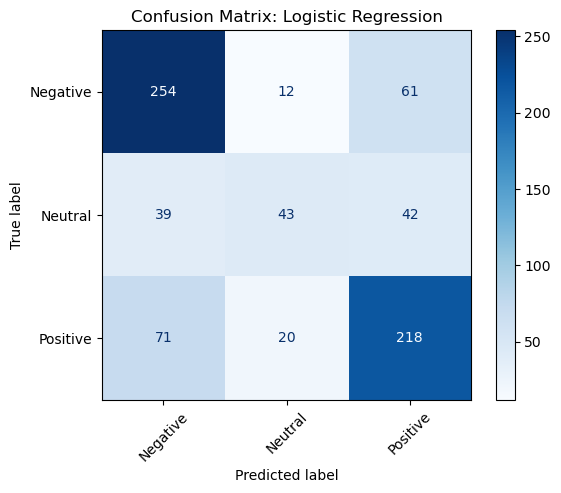

In [76]:
best_model_name = results.iloc[0]["Model"]

if best_model_name == "Logistic Regression":
    final_preds = lr_preds
elif best_model_name == "Multinomial Naive Bayes":
    final_preds = nb_preds
else:
    final_preds = svm_preds

cm = confusion_matrix(y_test, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows that the Logistic Regression model performs best on the Negative and Positive classes, with 254 correct Negative predictions and 218 correct Positive predictions.
The Neutral class is more difficult for the model to classify, with only 43 correct predictions, and it is often confused with both Negative and Positive.
This suggests that strongly polarized tweets are easier for the model to distinguish, while neutral language overlaps more with the other sentiment categories.

## 9. Conclusion

Among the three models tested, Logistic Regression achieved the highest performance with an accuracy of approximately 0.68, outperforming both Multinomial Naive Bayes and LinearSVC.

This result is consistent with expectations for text classification tasks. TF-IDF produces a high-dimensional and sparse feature space, which is well-suited for linear models such as Logistic Regression and LinearSVC. Logistic Regression slightly outperformed LinearSVC, likely due to its probabilistic framework and ability to better handle class boundaries in this dataset.

Multinomial Naive Bayes performed worse in comparison, likely due to its strong assumption of feature independence, which does not fully capture the relationships between words in text data.

The confusion matrix further shows that the model performs best on the Negative and Positive classes, while the Neutral class is more difficult to classify. This suggests that strongly polarized language is easier to detect, whereas neutral sentiment overlaps with both classes.

Overall, the results demonstrate that TF-IDF combined with Logistic Regression is an effective approach for sentiment classification of tweet data.

Future improvements could include expanding the hyperparameter search space, incorporating n-gram tuning, or exploring more advanced models such as gradient boosting or deep learning approaches.